In [ ]:
import uproot
import matplotlib.pyplot as plt
import pandas as pd
import tqdm
import numpy as np
import os
import glob
import awkward as ak
import boost_histogram as bh
import mplhep
from matplotlib.colors import LogNorm
# !pip install pyarrow
# !pip install "pyarrow<21" --break-system-packages

In [ ]:
runs_F222 = [7733, 8712]
runs_F223 = [8713, 9188]

runs_F231 = [10555, 11470]
runs_F232 = [11470, 11703]

runs_F241 = [14399, 15026]
runs_tungsten = [15030, 15594]
runs_F242 = [15652, 15820]
runs_caloNu = [15821, 16924]
runs_F243 = [16928, 17230]

runs_2022 = [8025, 9188]
runs_2023 = [10604, 11703]

runs_2024_preCaloNu = [14399, 15821]
runs_2024_CaloNu = [15821, 16924]
runs_2024_afterCaloNu = [16928, 17230]

In [33]:
def parse_grl_csv(file_path):
    grl_df = pd.read_csv(file_path)
    return grl_df

grl_2022_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2022_physics.csv")
grl_2023_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2023_physics.csv")
grl_2024_df = parse_grl_csv("/cvmfs/faser.cern.ch/repo/sw/runlist/v10/faser_goodrunlist_2024_physics.csv")
grl_df = pd.concat([grl_2022_df, grl_2023_df, grl_2024_df], ignore_index=True)

In [61]:
def get_cutflow_and_yields_for_run_range(files, run_start=None, run_end=None, mass=1.1):
    cutflow_dict = {}
    run_yields = {}

    total_lumi = 0
    for fpath in tqdm.tqdm(files):

        run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
        # if run not in good_runs: continue
        
        
        if run_start is not None and run_start > run:
            continue
        if run_end is not None and run > run_end:
            continue

        with uproot.open(fpath) as f:
            tree = f["cutflow"]
            lumi = f["meta"].arrays(library="pd")["lumi"][0]
            df = tree.arrays(library="pd")

            run = int(os.path.basename(fpath).split("/")[-1].split(".")[0])
            # if run not in good_runs: continue


            if "initial" not in cutflow_dict:
                cutflow_dict["initial"] = {"all": 0, "passed": 0}
                
            cutflow_dict["initial"]["all"] += df["all"].max()
            cutflow_dict["initial"]["passed"] += df["passed"].max()
            cutflow_dict["initial"]["efficiency"] = 1
            cutflow_dict["initial"]["cumulative_efficiency"] = 1

            
            # total_lumi += lumi[0] / 1000 # /pb -> /fb
            lumi_row = grl_df[grl_df["Run"] == run]
            if not lumi_row.empty:
                total_lumi += lumi_row[" LumiRec"].values[0] / 1000  # /pb -> /fb

            for idx, row in df.iterrows():
                cut = row["cut_name"]
                all = row["all"]
                passed = row["passed"]

                if cut not in cutflow_dict:
                    cutflow_dict[cut] = {"all": 0, "passed": 0}

                cutflow_dict[cut]["all"] += all
                cutflow_dict[cut]["passed"] += passed
                cutflow_dict[cut]["efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[cut]["all"] if cutflow_dict[cut]["all"] > 0 else 0
                cutflow_dict[cut]["cumulative_efficiency"] = cutflow_dict[cut]["passed"] / cutflow_dict[list(cutflow_dict.keys())[0]]["all"] if cutflow_dict[list(cutflow_dict.keys())[0]]["all"] > 0 else 0
                cutflow_dict[cut]["efficiency_error"] = np.sqrt(cutflow_dict[cut]["efficiency"] * (1 - cutflow_dict[cut]["efficiency"]) / cutflow_dict[cut]["all"]) if cutflow_dict[cut]["all"] > 0 else 0


                final_yield = np.amin(df["passed"])
                run_yields[int(run)] = final_yield

    if total_lumi <= 0:
        total_lumi = 10_000

    print(f"Total lumi for runs {run_start} to {run_end}: {total_lumi:.2f} fb^-1")

    cutflow = pd.DataFrame.from_dict(cutflow_dict, orient="index")
    cutflow["rate [events/fb/tonne]"] = cutflow["passed"] / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow["rate_error [events/fb/tonne]"] = np.sqrt(cutflow["passed"]) / (total_lumi * mass) if total_lumi > 0 else 0
    cutflow = cutflow.sort_values(by='passed', ascending=False)
            
    return cutflow, run_yields

In [62]:
data_files = glob.glob("AnalysisZipFramework/submission/analysis_output/*.root")

calonu_data_files = []
non_caloNu_2024_data_files = []

for file in data_files:
    run_num = int(os.path.basename(file).split('.')[0])

    if runs_caloNu[0] <= run_num <= runs_caloNu[1]:
        calonu_data_files.append(f"{file}")
    if runs_2024_preCaloNu[0] <= run_num <= runs_2024_preCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    if runs_2024_afterCaloNu[0] <= run_num <= runs_2024_afterCaloNu[1]:
        non_caloNu_2024_data_files.append(f"{file}")
    

In [63]:
noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = non_caloNu_2024_data_files, mass=1.1)

100%|██████████| 146/146 [00:02<00:00, 63.79it/s]

Total lumi for runs None to None: 50.10 fb^-1


In [64]:
withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = calonu_data_files, mass=0.68)

100%|██████████| 130/130 [00:02<00:00, 63.14it/s]

Total lumi for runs None to None: 70.03 fb^-1


In [65]:
display(noCaloNu_cutflow_df)

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne],rate_error [events/fb/tonne]
initial,832303949,826333197,1.000000,1.000000e+00,NaN,1.499515e+07,521.642930
Colliding,832303949,826333197,0.992826,9.928262e-01,2.925292e-06,1.499515e+07,521.642930
Trigger,826333197,826332677,0.999999,9.928256e-01,2.759601e-08,1.499514e+07,521.642766
Good times,826332677,824274064,0.997509,9.903522e-01,1.734166e-06,1.495779e+07,520.992586
Excluded times,824274064,823110824,0.998589,9.889546e-01,1.307544e-06,1.493668e+07,520.624836
Sanity cut to remove events with missing aux data,823110824,823110824,1.000000,9.889546e-01,0.000000e+00,1.493668e+07,520.624836
VetoNu0 reduced charge < 30 pC,823110824,15598745,0.018951,1.874164e-02,4.752607e-06,2.830645e+05,71.670520
VetoNu1 reduced charge < 30 pC,15598745,15179319,0.973112,1.823771e-02,4.095617e-05,2.754533e+05,70.700400
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),15179319,15118205,0.995974,1.816428e-02,1.625332e-05,2.743443e+05,70.557932
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),15118205,15118134,0.999995,1.816420e-02,5.573499e-07,2.743430e+05,70.557766


In [66]:
display(withCaloNu_cutflow_df)

,all,passed,efficiency,cumulative_efficiency,efficiency_error,rate [events/fb/tonne],rate_error [events/fb/tonne]
initial,1171359011,1166047346,1.000000,1.000000e+00,NaN,2.448521e+07,717.043987
Colliding,1171359011,1166047346,0.995465,9.954654e-01,1.963082e-06,2.448521e+07,717.043987
Trigger,1166047346,1166045203,0.999998,9.954636e-01,3.970037e-08,2.448517e+07,717.043328
Good times,1166045203,1165424879,0.999468,9.949340e-01,6.752714e-07,2.447214e+07,716.852572
Excluded times,1165424879,1164870204,0.999524,9.944604e-01,6.388982e-07,2.446050e+07,716.681962
Sanity cut to remove events with missing aux data,1164870204,1164870204,1.000000,9.944604e-01,0.000000e+00,2.446050e+07,716.681962
VetoNu0 reduced charge < 30 pC,1164870204,21536358,0.018488,1.838579e-02,3.946902e-06,4.522306e+05,97.448203
VetoNu1 reduced charge < 30 pC,21536358,21017051,0.975887,1.794245e-02,3.305518e-05,4.413260e+05,96.266148
VetoNu0 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),21017051,20929588,0.995838,1.786778e-02,1.404219e-05,4.394894e+05,96.065632
VetoNu1 raw charge < 40 pC (fallback to raw charge if reduced charge invalid),20929588,20929513,0.999996,1.786772e-02,4.137797e-07,4.394878e+05,96.065460


In [73]:
def plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df):

    fig, ax = plt.subplots(figsize=(20, 10), nrows=2, ncols=1, sharex=True)
    ax[0].bar(noCaloNu_cutflow_df.index, noCaloNu_cutflow_df["rate [events/fb/tonne]"], label="No caloNu", alpha=0.7)
    ax[0].bar(withCaloNu_cutflow_df.index, withCaloNu_cutflow_df["rate [events/fb/tonne]"], label="With caloNu", alpha=0.7)
    ax[0].set_yscale("log")
    ax[0].set_ylabel("Rate [events/fb/tonne]")
    ax[0].set_title("Cutflow Comparison: No caloNu vs With caloNu")
    ax[0].legend()
    ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")

    ratio = withCaloNu_cutflow_df["rate [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"]
    ratio_error = np.sqrt((withCaloNu_cutflow_df["rate_error [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"])**2 + (withCaloNu_cutflow_df["rate [events/fb/tonne]"] * noCaloNu_cutflow_df["rate_error [events/fb/tonne]"] / noCaloNu_cutflow_df["rate [events/fb/tonne]"]**2)**2)
    ax[1].errorbar(noCaloNu_cutflow_df.index, ratio, yerr=ratio_error, color="gray", alpha=0.7, capsize=5, linestyle='None', marker='o')
    # ax[1].bar(noCaloNu_cutflow_df.index, ratio, color="gray", alpha=0.7)
    # ax[1].set_ylabel("Ratio (With caloNu / No caloNu)")
    # ax[1].set_xlabel("Cut Name")
    ax[1].set_ylabel("Ratio \n (With caloNu / No caloNu)")
    ax[1].axhline(1, color="red", linestyle="--")
    plt.tight_layout()


/tmp/ipykernel_3829322/3347822580.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(noCaloNu_cutflow_df.index, rotation=45, ha="right")


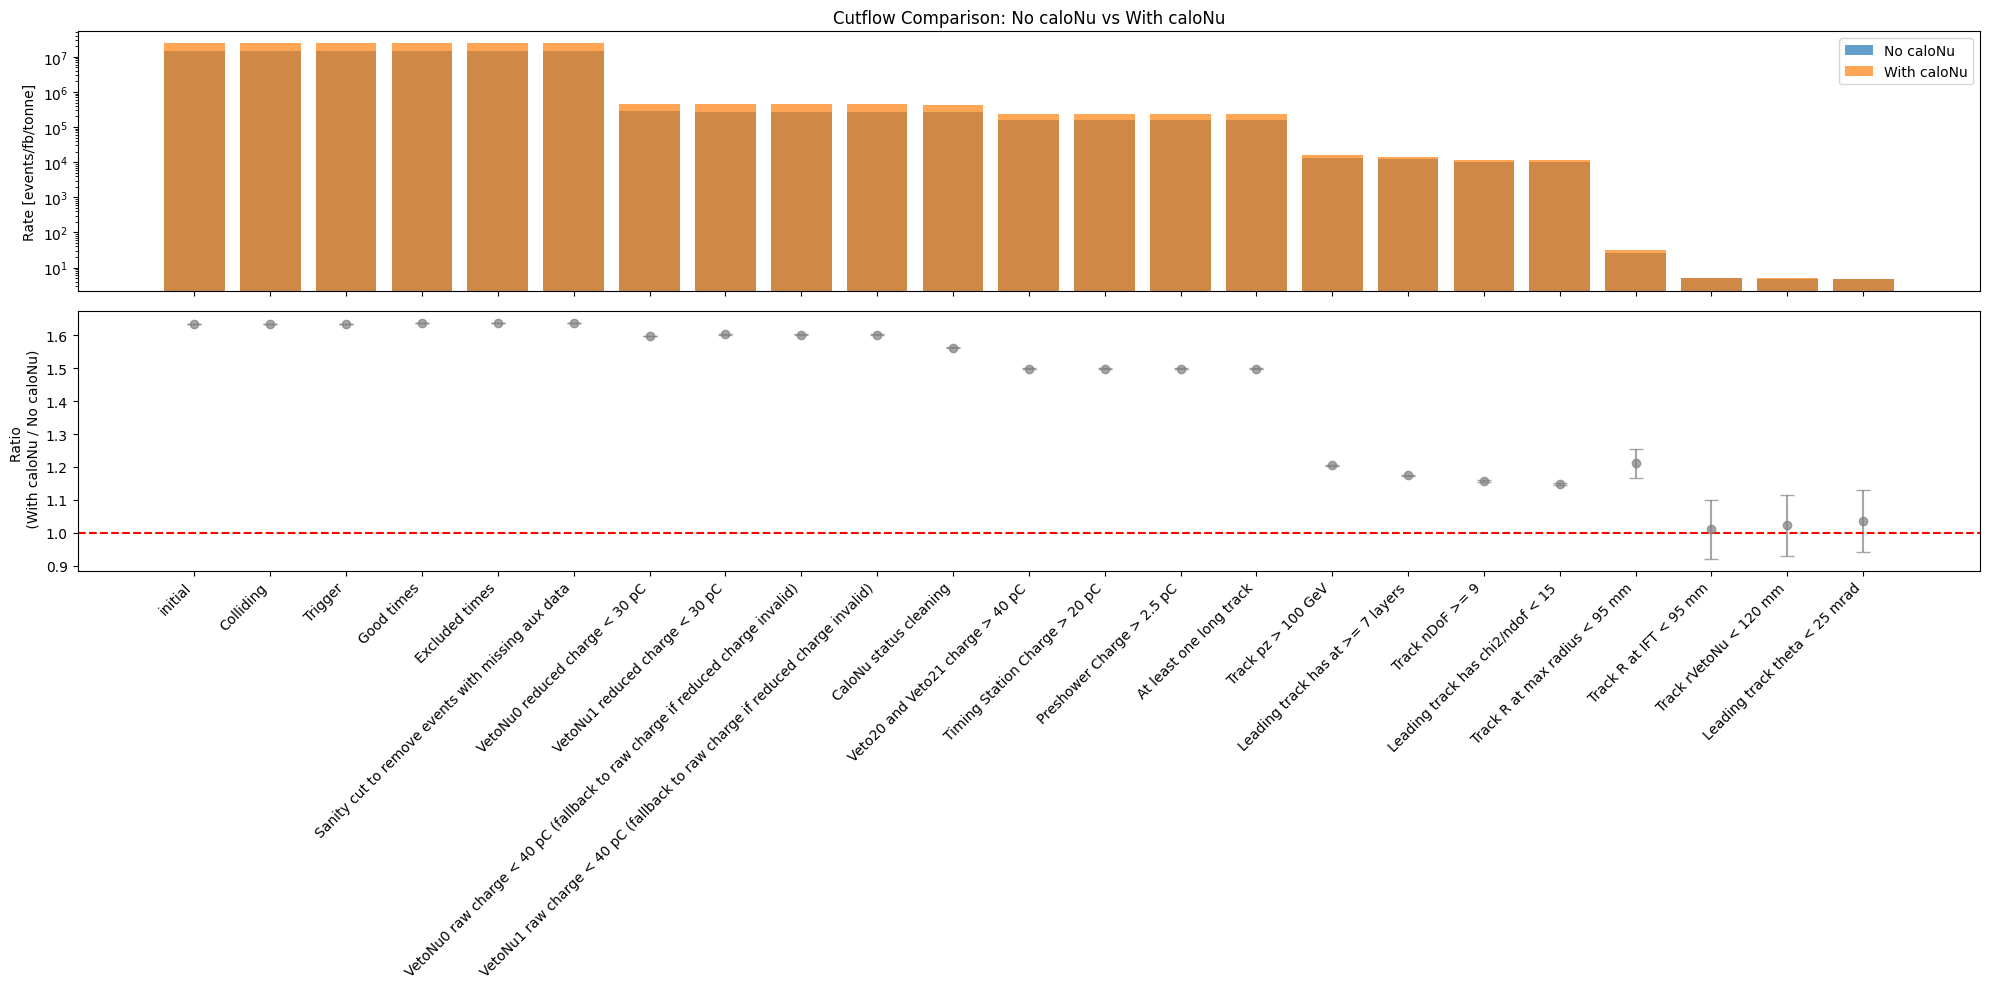

In [74]:
plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

In [69]:
# noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200093.root"], mass=1.1)
# withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200139.root"], mass=0.68)
# plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

In [70]:
# noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200094.root"], mass=1.1)
# withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200140.root"], mass=0.68)
# plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

In [71]:
# noCaloNu_cutflow_df, noCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200100.root"], mass=1.1)
# withCaloNu_cutflow_df, withCaloNu_run_yields = get_cutflow_and_yields_for_run_range(files = ["build/200146.root"], mass=0.68)
# plot_cutflow_comparison(noCaloNu_cutflow_df, withCaloNu_cutflow_df)

In [72]:
data_noCaloNu = uproot.concatenate(["build/200093.root:nt", "build/200094.root:nt", "build/200100.root:nt"], filter_name=["crossingAngle"])
data_withCaloNu = uproot.concatenate(["build/200139.root:nt", "build/200140.root:nt", "build/200146.root:nt"], filter_name=["crossingAngle"])

FileNotFoundError: [Errno 2] No such file or directory: '/opt/ppd/atlas/bewilson/nuAnalysis/build/200093.root'

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))
# bins = np.linspace(-0.5, 0.5, 50)
bins=50
ax.hist(data_noCaloNu["crossingAngle"], bins=bins, alpha=0.5, label="No caloNu", density=True)
ax.hist(data_withCaloNu["crossingAngle"], bins=bins, alpha=0.5, label="With caloNu", density=True)
ax.set_xlabel("Crossing Angle")
ax.set_ylabel("Normalized Counts")
ax.set_title("Crossing Angle Distribution: No caloNu vs With caloNu")
ax.legend()

In [ ]:
print(set(data_noCaloNu["crossingAngle"]))
print(set(data_withCaloNu["crossingAngle"]))